## Fake News system that classify and predict the news either real or fake.
 *NOTE:* i have used "WELFAKE" dataset from the kaggle which has some issues i then preprocessed those issues and removed most of them and then created a new dataset and used it, if you wanted to check that dataset just search its name "WELfake dataset" and you will find it on the kaggle, the changes i have made are mentioned below.
 1. i have completely removed the unnamed column beacuse i think its not worthy to either merge it or to use it.
 2. i have merged both "title" and "text" columns and create a new column named "text"
 3. i have changed the values of label from 0 and 1 to ( 0 for fake and 1 for real) to dealt later and use encoder for better result.
 4. i then removed all duplicates and missing values.
 5. and lastly i saved the dataset for training the model and further processing.
 
 if you find any other issues or the dataset has not cleaned and preprocessed correctly you can check that dataset.

Step 1: Importing libraies.

In [43]:
# import all the necessary libraries for the project
# Core
import pandas as pd
import numpy as np
import os
import json

# NLP
import re
import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('omw-1.4')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve

# import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Save model
import pickle

# remove warnings
import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Saif Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Saif
[nltk_data]     Ullah\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


step 2: import data and start working on the model

In [44]:
#import the dataset and display basic information about it
df = pd.read_csv('news_dataset.csv')

print(" DATASET INFORMATION")

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

# drop any missing values and duplicates
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Display first few rows
print("FIRST 5 ROWS")
df.head()

 DATASET INFORMATION
Dataset Shape: (71231, 2)

Columns: ['text', 'label']
FIRST 5 ROWS


,text,label
0,law enforcement high alert follow threat cop white number blacklivesmatter fyf number terrorist ...,real
1,unbelievable obama attorney general say charlotte rioter peaceful protester home state north car...,real
2,bobby jindal raise hindu us story christian conversion woo evangelicals potential number bid doz...,fake
3,satan number russia unvelis image terrify new supernuke western world take notice number sarmat ...,real
4,time christian group sue amazon splc designation hate group say one time someone sue southern po...,real


In [45]:
#change the column and rows to display all the data
# Configure display options

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 100)

In [46]:
# check for any missing, null values in the dataset and duplicates values.
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate values:", df.duplicated().sum())

Missing values:
 text     0
label    0
dtype: int64

Duplicate values: 0


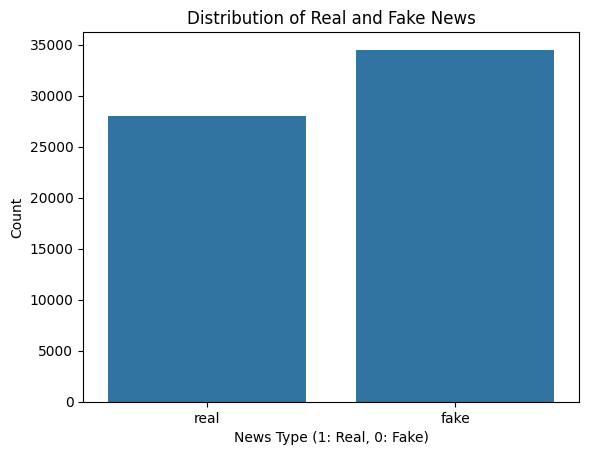

In [47]:
# visulaize the distribution of the target variable
sns.countplot(x='label', data=df)
plt.title('Distribution of Real and Fake News')
plt.xlabel('News Type (1: Real, 0: Fake)')
plt.ylabel('Count')

#save this to the figures folder
plt.savefig('figures/news_distribution.png')
plt.show()

step 3: preprocess the data for model training

In [48]:
#data preprocessing with POS-based lemmatization

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text)

    # lowercase
    text = text.lower()

    # remove urls and html
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)

    # normalize currency and numbers
    text = re.sub(r'\$\s?\d+(\.\d+)?', ' money ', text)
    text = re.sub(r'\d+(\.\d+)?', ' number ', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # normalize repeated characters (gooooood → good)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # tokenize
    tokens = word_tokenize(text)

    # pos tagging
    pos_tags = pos_tag(tokens)

    # pos mapping
    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return 'a'
        elif tag.startswith('V'):
            return 'v'
        elif tag.startswith('N'):
            return 'n'
        elif tag.startswith('R'):
            return 'r'
        return 'n'

    cleaned_words = []

    for word, tag in pos_tags:
        if word not in stop_words and len(word) > 2:
            lemma = lemmatizer.lemmatize(word, get_wordnet_pos(tag))
            cleaned_words.append(lemma)

    # remove consecutive duplicate words
    final_words = []
    for word in cleaned_words:
        if not final_words or final_words[-1] != word:
            final_words.append(word)

    text = ' '.join(final_words)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [49]:
# apply the preprocessing function to the 'text' column
df['text'] = df['text'].apply(preprocess_text)
df = df[df['text'].str.strip() != ""]

step 4: encode the targeted variables.

In [50]:
# encode the target variable using label encoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [51]:
# checking the encoded target variable to see which number is assigned to which label
encoded_labels = dict(zip(le.classes_, le.transform(le.classes_)))
print("Encoded labels (Language → Numeric):\n", encoded_labels)

Encoded labels (Language → Numeric):
 {'fake': 0, 'real': 1}


step 5: separate the data into features and target variables.

In [52]:
#Now we will separate the features and the target variable, for further processing and model training
X = df['text']
y = df['label'].astype(int)

In [53]:
# check x and y shapes
print(X.shape)
print(y.shape)

(62546,)
(62546,)


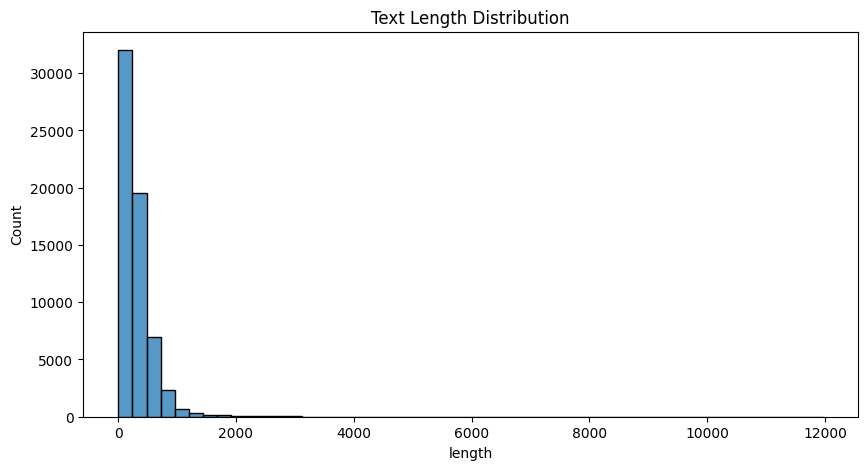

In [54]:
# checkung the distribution of text length in the dataset
df['length'] = df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.histplot(df['length'], bins=50)
plt.title("Text Length Distribution")
#save this to the figures folder
plt.savefig('figures/text_length_distribution.png')
plt.show()

step 6: Applying TFIDF vectorization on the data.

In [55]:
#apply advanced word-level tf-idf vectorization
# this tf-idf configuration is optimized for fake news detection
# word-level analysis works best for semantic understanding
# bigrams help capture context like "fake news" or "breaking news"

vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=10000,
    max_df=0.85,
    min_df=5,
    sublinear_tf=True,
    strip_accents='unicode',
    use_idf=True,
    smooth_idf=True
)

# convert text into feature vectors
X = vectorizer.fit_transform(df['text'])

# target labels
y = df['label']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (62546, 10000)
Target Shape: (62546,)


step 7: train test split the data into training and testing sets.

In [56]:
#train test split the data into training and testing sets
X_train, X_test, y_train, y_test, text_train, text_test = train_test_split(
    X, y, df['text'],
    test_size=0.2,
    stratify=y,
    random_state=42
)


step 8: Define models with optimized hyperparameters

In [57]:
#define models with OPTIMIZED hyperparameters (faster training)
# IMPORTANT: Use fewer iterations and simpler models for faster training
models = {

    'Logistic Regression': {
        'model': LogisticRegression(
            random_state=42,
            max_iter=500,  # Reduced from 1000
            solver='liblinear',  # Faster than saga for smaller datasets
            class_weight='balanced'
        ),
        'params': {
            'C': [0.1, 1.0, 10.0],  # Reduced options
        }
    },

    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0]
        }
    },

    'Random Forest': {
        'model': RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            n_estimators=50,  # Reduced from 100-200
            max_depth=15,  # Limit depth
            min_samples_split=10  # Increase to prevent overfitting and speed up
        ),
        'params': {
            'n_estimators': [50, 100],  # Fewer options
            'max_depth': [10, 15]
        }
    }
}

print("✅ Models defined with optimized parameters for faster training")
print("   - Logistic Regression: liblinear solver")
print("   - Random Forest: limited to 50-100 trees")
print("   - Naive Bayes: standard settings")

✅ Models defined with optimized parameters for faster training
   - Logistic Regression: liblinear solver
   - Random Forest: limited to 50-100 trees
   - Naive Bayes: standard settings


step 9: Train and evaluate models using Randomizedsearchcv

In [58]:
# Train and evaluate models with RandomizedSearchCV
results = {}
all_models = {}
roc_auc = 0
best_model = None
best_f1 = 0
best_model_name = ""

# Take a subset for faster training if needed (optional)
# Uncomment the lines below to use 50% of data for faster training
# from sklearn.utils import resample
# X_train_small, y_train_small = resample(X_train, y_train, n_samples=min(20000, len(X_train)), random_state=42)
# print(f"Using subset: {len(X_train_small)} samples for faster training")
# training_X = X_train_small
# training_y = y_train_small

training_X = X_train
training_y = y_train

print(f"\n Training on {training_X.shape[0]} samples with {training_X.shape[1]} features")

for name, config in models.items():

    print(f"\n{'='*50}")
    print(f" Training {name}...")
    print(f"{'='*50}")

    # Use fewer iterations for faster training
    random_search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=5,  
        scoring='f1',
        cv=5,  
        verbose=1,  # Shows progress
        random_state=42,
        n_jobs=-1
    )

    # Train model (this will show progress)
    random_search.fit(training_X, training_y)
    trained_model = random_search.best_estimator_

    # Predictions
    y_pred = trained_model.predict(X_test)

    # Probabilities for ROC-AUC
    if hasattr(trained_model, "predict_proba"):
        try:
            y_prob = trained_model.predict_proba(X_test)
            if y_prob.shape[1] == 2:
                roc_auc = roc_auc_score(y_test, y_prob[:, 1])
            else:
                roc_auc = 0
        except:
            roc_auc = 0
    else:
        roc_auc = 0

    # Save model
    all_models[name] = trained_model

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Store results
    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "Best Params": random_search.best_params_
    }

    # Best model selection
    if f1 > best_f1:
        best_f1 = f1
        best_model = trained_model
        best_model_name = name
    
    print(f" {name} completed - F1: {f1:.4f}")

# Results summary
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="F1 Score", ascending=False)

print("\n" + "="*60)
print(" MODEL COMPARISON RESULTS")
print("="*60)
print(results_df)

print("\n" + "="*60)
print("🏆 BEST MODEL")
print("="*60)
print(f"Model: {best_model_name}")
print(f"Weighted F1 Score: {best_f1:.4f}")
print(f"Best Parameters: {results_df.loc[best_model_name, 'Best Params']}")

# Generate predictions for later use
y_pred_best = best_model.predict(X_test)
print(f"\n Predictions generated for {len(y_pred_best)} test samples")

# Save results
results_df.to_csv("figures/model_results.csv")
print("\n Results saved to figures/model_results.csv")


 Training on 50036 samples with 10000 features

 Training Logistic Regression...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
 Logistic Regression completed - F1: 0.9671

 Training Naive Bayes...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
 Naive Bayes completed - F1: 0.8647

 Training Random Forest...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
 Random Forest completed - F1: 0.9237

 MODEL COMPARISON RESULTS
                    Accuracy Precision  Recall F1 Score ROC-AUC  \
Logistic Regression   0.9671    0.9671  0.9671   0.9671  0.9949   
Random Forest         0.9239    0.9244  0.9239   0.9237  0.9813   
Naive Bayes           0.8644    0.8665  0.8644   0.8647  0.9414   

                                                Best Params  
Logistic Regression                             {'C': 10.0}  
Random Forest        {'n_estimators': 100, 'max_depth': 15}  
Naive Bayes                                  {'alpha': 0.1}  

🏆 BEST MODEL
Model: L

In [59]:
# classification report for the best model

print(" CLASSIFICATION REPORT")


# define classification report for the best model
report = classification_report(y_test, y_pred_best, target_names=['Fake', 'Real'])

print("\n" + report)

# Save report to file
with open("figures/classification_report.txt", "w") as f:
    f.write(report)

print("\n Classification report saved to figures/classification_report.txt")

# Additional metrics
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best).ravel()
print(f"\n Confusion Matrix Breakdown:")
print(f"   True Negatives (Correct Fake): {tn}")
print(f"   False Positives (Fake→Real): {fp}")
print(f"   False Negatives (Real→Fake): {fn}")
print(f"   True Positives (Correct Real): {tp}")

 CLASSIFICATION REPORT

              precision    recall  f1-score   support

        Fake       0.97      0.97      0.97      6903
        Real       0.96      0.96      0.96      5607

    accuracy                           0.97     12510
   macro avg       0.97      0.97      0.97     12510
weighted avg       0.97      0.97      0.97     12510


 Classification report saved to figures/classification_report.txt

 Confusion Matrix Breakdown:
   True Negatives (Correct Fake): 6695
   False Positives (Fake→Real): 208
   False Negatives (Real→Fake): 203
   True Positives (Correct Real): 5404


 MODEL COMPARISON BAR CHART


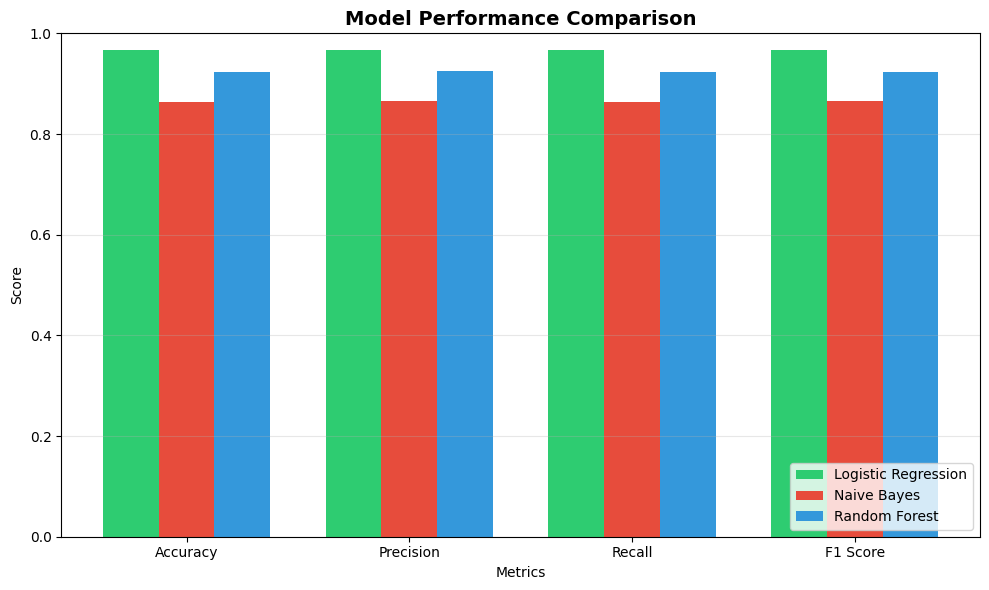

 Model comparison chart saved to figures/model_comparison.png


In [60]:
#Model Comparison Visualization to see the performance of all the models in a bar chart
# This visualization helps us quickly compare the key performance metrics of each model side by side.
# This visualization also shows us which model performs best across multiple metrics, not just F1 Score.

print(" MODEL COMPARISON BAR CHART")


# Create comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

colors = ['#2ecc71', '#e74c3c', '#3498db']
for i, (model_name, metrics) in enumerate(results.items()):
    values = [metrics[m] for m in metrics_to_plot]
    ax.bar(x + i*width, values, width, label=model_name, color=colors[i])

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150)
plt.show()
print(" Model comparison chart saved to figures/model_comparison.png")

step 10: Cross validation Analysis

In [61]:
# Cross-validation analysis

# Make sure y is numeric for cross-validation
if isinstance(y, pd.Series):
    if y.dtype == object or isinstance(y.iloc[0], str):
        y = LabelEncoder().fit_transform(y)
    else:
        y = y.values
elif isinstance(y, np.ndarray):
    if y.dtype == object or isinstance(y[0], str):
        y = LabelEncoder().fit_transform(y)
else:
    y = np.asarray(y)

# 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, val_idx in skf.split(X, y):
    # Split data
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    # Train and predict
    best_model.fit(X_train_fold, y_train_fold)
    y_pred = best_model.predict(X_val_fold)
    
    # Calculate F1 score
    f1 = f1_score(y_val_fold, y_pred, average='weighted')
    scores.append(f1)

# Display results
print(f"\nF1 Scores: {[round(s, 4) for s in scores]}")
print(f"Average F1: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")

# Save results
pd.DataFrame({'Fold': range(1,6), 'F1_Score': scores}).to_csv("figures/cv_results.csv", index=False)
print("\n Results saved to figures/cv_results.csv")



F1 Scores: [0.9683, 0.967, 0.9666, 0.9648, 0.9641]
Average F1: 0.9661 (+/- 0.0015)

 Results saved to figures/cv_results.csv


step 11: Checking ROC Curve Score

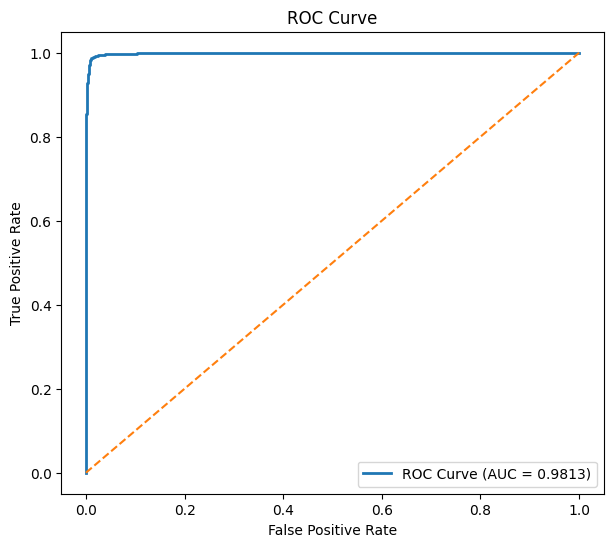

ROC curve saved successfully.


In [62]:
# roc curve visualization
# calculate false positive rate and true positive rate
# Convert y_test to numeric for roc_curve (it currently contains 'fake'/'real' strings)

y_test_numeric = LabelEncoder().fit_transform(y_test)

# Get probabilities from best model
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Calculate false positive rate and true positive rate
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_prob_best)

# create roc curve plot
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.4f})',
    linewidth=2
)

# random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

# labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

# legend
plt.legend(loc="lower right")

# save figure
plt.savefig("figures/roc_curve.png")

# show plot
plt.show()

print("ROC curve saved successfully.")

step 12: Confusion matrix and ROC curve score visualization

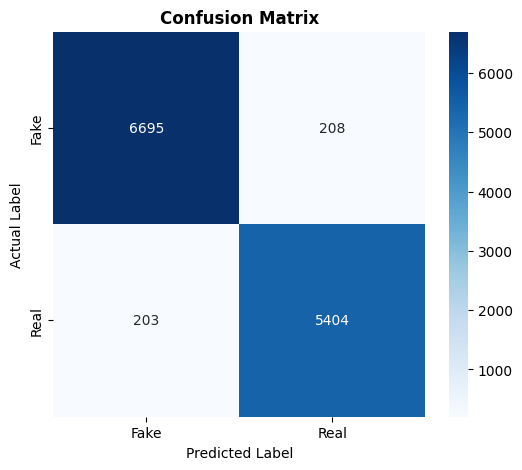

In [63]:
# Step: Confusion Matrix Visualization
# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# plot
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fake', 'Real'],
    yticklabels=['Fake', 'Real']
)

plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

# save figure
plt.savefig("figures/confusion_matrix.png", dpi=150, bbox_inches='tight')

plt.show()


step 13: Saving all the models for future use

In [64]:
# Save all models and components

# Save best model
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(" Best model saved: models/best_model.pkl")

# Save vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
print(" TF-IDF Vectorizer saved: models/tfidf_vectorizer.pkl")

# Save label encoder
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("Label encoder saved: models/label_encoder.pkl")

# Save all models comparison
results_df.to_csv('models/model_comparison.csv')
print("Model comparison saved: models/model_comparison.csv")

# Save model metadata
model_info = {
    'best_model_name': best_model_name,
    'best_f1_score': float(best_f1),
    'features_count': X.shape[1],
    'training_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'cv_mean_f1': float(np.mean(scores)),
    'cv_std_f1': float(np.std(scores))
}

# Add ROC-AUC if available
if 'roc_auc' in locals() and roc_auc:
    model_info['roc_auc'] = float(roc_auc)

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print(" Model metadata saved: models/model_info.json")

print("\n" + "="*60)
print("🎉 ALL MODELS SAVED SUCCESSFULLY!")
print("="*60)
print(f"\n📊 Model Summary:")
print(f"   Best Model: {best_model_name}")
print(f"   F1 Score: {best_f1:.4f}")
print(f"   Features: {X.shape[1]:,}")
print(f"   Training Samples: {X_train.shape[0]:,}")
print(f"   Test Samples: {X_test.shape[0]:,}")


 Best model saved: models/best_model.pkl
 TF-IDF Vectorizer saved: models/tfidf_vectorizer.pkl
Label encoder saved: models/label_encoder.pkl
Model comparison saved: models/model_comparison.csv
 Model metadata saved: models/model_info.json

🎉 ALL MODELS SAVED SUCCESSFULLY!

📊 Model Summary:
   Best Model: Logistic Regression
   F1 Score: 0.9671
   Features: 10,000
   Training Samples: 50,036
   Test Samples: 12,510


step 14: batch prediction function

In [65]:

# Batch prediction function with column selection support
def batch_predict_news(input_file, output_file, text_column='text'):
    """
    Perform batch fake news prediction on CSV data.
    
    Parameters:
    ----------
    input_file : str
        Path of input CSV file containing news text.
    output_file : str
        Path where prediction results will be saved.
    text_column : str
        Name of the column containing text (default: 'text')
    
    Returns:
    -------
    batch_df : DataFrame
        DataFrame with predictions added
    """
    
    # Check if input file exists
    if not os.path.exists(input_file):
        print(f"\n❌ File not found: {input_file}")
        return None
    
    # Load csv file
    batch_df = pd.read_csv(input_file)
    print(f"\n📊 Loaded {len(batch_df)} rows from {input_file}")
    print(f"   Columns: {batch_df.columns.tolist()}")
    
    # Check for text column
    if text_column not in batch_df.columns:
        print(f"\n⚠️ Column '{text_column}' not found!")
        print(f"   Available columns: {batch_df.columns.tolist()}")
        
        # Try to auto-detect text column
        text_candidates = ['text', 'news', 'article', 'content', 'headline', 'title']
        found_col = None
        
        for col in text_candidates:
            if col in batch_df.columns:
                found_col = col
                break
        
        if found_col:
            print(f"   ✅ Using column: '{found_col}'")
            text_column = found_col
        else:
            print("\n❌ No text column found. Please ensure CSV has a 'text' column")
            return None
    
    # Preprocess text
    print("\n⏳ Preprocessing text...")
    batch_df['clean_text'] = batch_df[text_column].apply(preprocess_text)
    
    # Remove empty texts
    batch_df = batch_df[batch_df['clean_text'].str.strip() != ""]
    print(f"   After cleaning: {len(batch_df)} rows")
    
    # Vectorize text
    print("⏳ Vectorizing text...")
    X_batch = vectorizer.transform(batch_df['clean_text'])
    
    # Get predictions and probabilities
    print("⏳ Making predictions...")
    probabilities = best_model.predict_proba(X_batch)
    predictions = best_model.predict(X_batch)
    confidence_scores = probabilities.max(axis=1)
    
    # Map labels (handle both string and numeric)
    if isinstance(predictions[0], str):
        # If predictions are strings
        batch_df['prediction'] = predictions
    else:
        # If predictions are numeric
        label_map = {1: "REAL", 0: "FAKE"}
        batch_df['prediction'] = [label_map.get(p, "UNKNOWN") for p in predictions]
    
    # Add confidence scores
    batch_df['confidence'] = confidence_scores.round(4)
    batch_df['fake_prob'] = probabilities[:, 0].round(4)
    batch_df['real_prob'] = probabilities[:, 1].round(4)
    
    # Confidence categories
    batch_df['confidence_level'] = np.where(
        confidence_scores > 0.90, "Very High",
        np.where(confidence_scores > 0.75, "High",
        np.where(confidence_scores > 0.60, "Moderate", "Low")))
    
    # Save output file
    batch_df.to_csv(output_file, index=False)
    
    # Print summary
    print("\n" + "="*50)
    print("📊 BATCH PREDICTION SUMMARY")
    print("="*50)
    print(f"Total processed: {len(batch_df)}")
    print(f"REAL news: {(batch_df['prediction'] == 'REAL').sum()}")
    print(f"FAKE news: {(batch_df['prediction'] == 'FAKE').sum()}")
    print(f"Avg confidence: {batch_df['confidence'].mean():.3f}")
    print(f"\n✅ Results saved to: {output_file}")
    
    return batch_df



step 15: single text prediction

In [66]:
# function to predict news with confidence scores and probabilities
def predict_news(text):

    cleaned = preprocess_text(text)

    X_input = vectorizer.transform([cleaned])

    probabilities = best_model.predict_proba(X_input)[0]

    prediction = np.argmax(probabilities)

    confidence = np.max(probabilities)

    label = "REAL" if prediction == 1 else "FAKE"

    return {
        "prediction": label,
        "confidence": round(confidence, 4),
        "fake_probability": round(probabilities[0], 4),
        "real_probability": round(probabilities[1], 4)
    }

step 16: Showing top important words

In [67]:
# showing top important words

feature_names = vectorizer.get_feature_names_out()

if hasattr(best_model, "coef_"):

    coefficients = best_model.coef_[0]

elif hasattr(best_model, "feature_importances_"):

    coefficients = best_model.feature_importances_

else:
    coefficients = None

if coefficients is not None:

    top_fake = np.argsort(coefficients)[:20]
    top_real = np.argsort(coefficients)[-20:]

    print("\nTop Fake News Words:")
    print([feature_names[i] for i in top_fake])

    print("\nTop Real News Words:")
    print([feature_names[i] for i in top_real])

else:
    print("\nFeature importance not supported.")


Top Fake News Words:
['reuters', 'breitbart', 'york time', 'twitter', 'washington reuters', 'say', 'president donald', 'follow twitter', 'jerome', 'thursday', 'two candidate', 'reuters president', 'friday', 'moscow reuters', 'todd', 'new york', 'hudson', 'sunday', 'factbox', 'say statement']

Top Real News Words:
['wow', 'president trump', 'flickr', 'source', 'wire', 'anti', 'hillary', 'image via', 'getty image', 'getty', 'read', 'entire story', 'image', 'october number', 'via breitbart', 'video', 'twitter com', 'november number', 'feature image', 'via']
